<a href="https://colab.research.google.com/github/AliSalman25/first-Jupyter-Notebook-for-the-experiments/blob/main/first_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

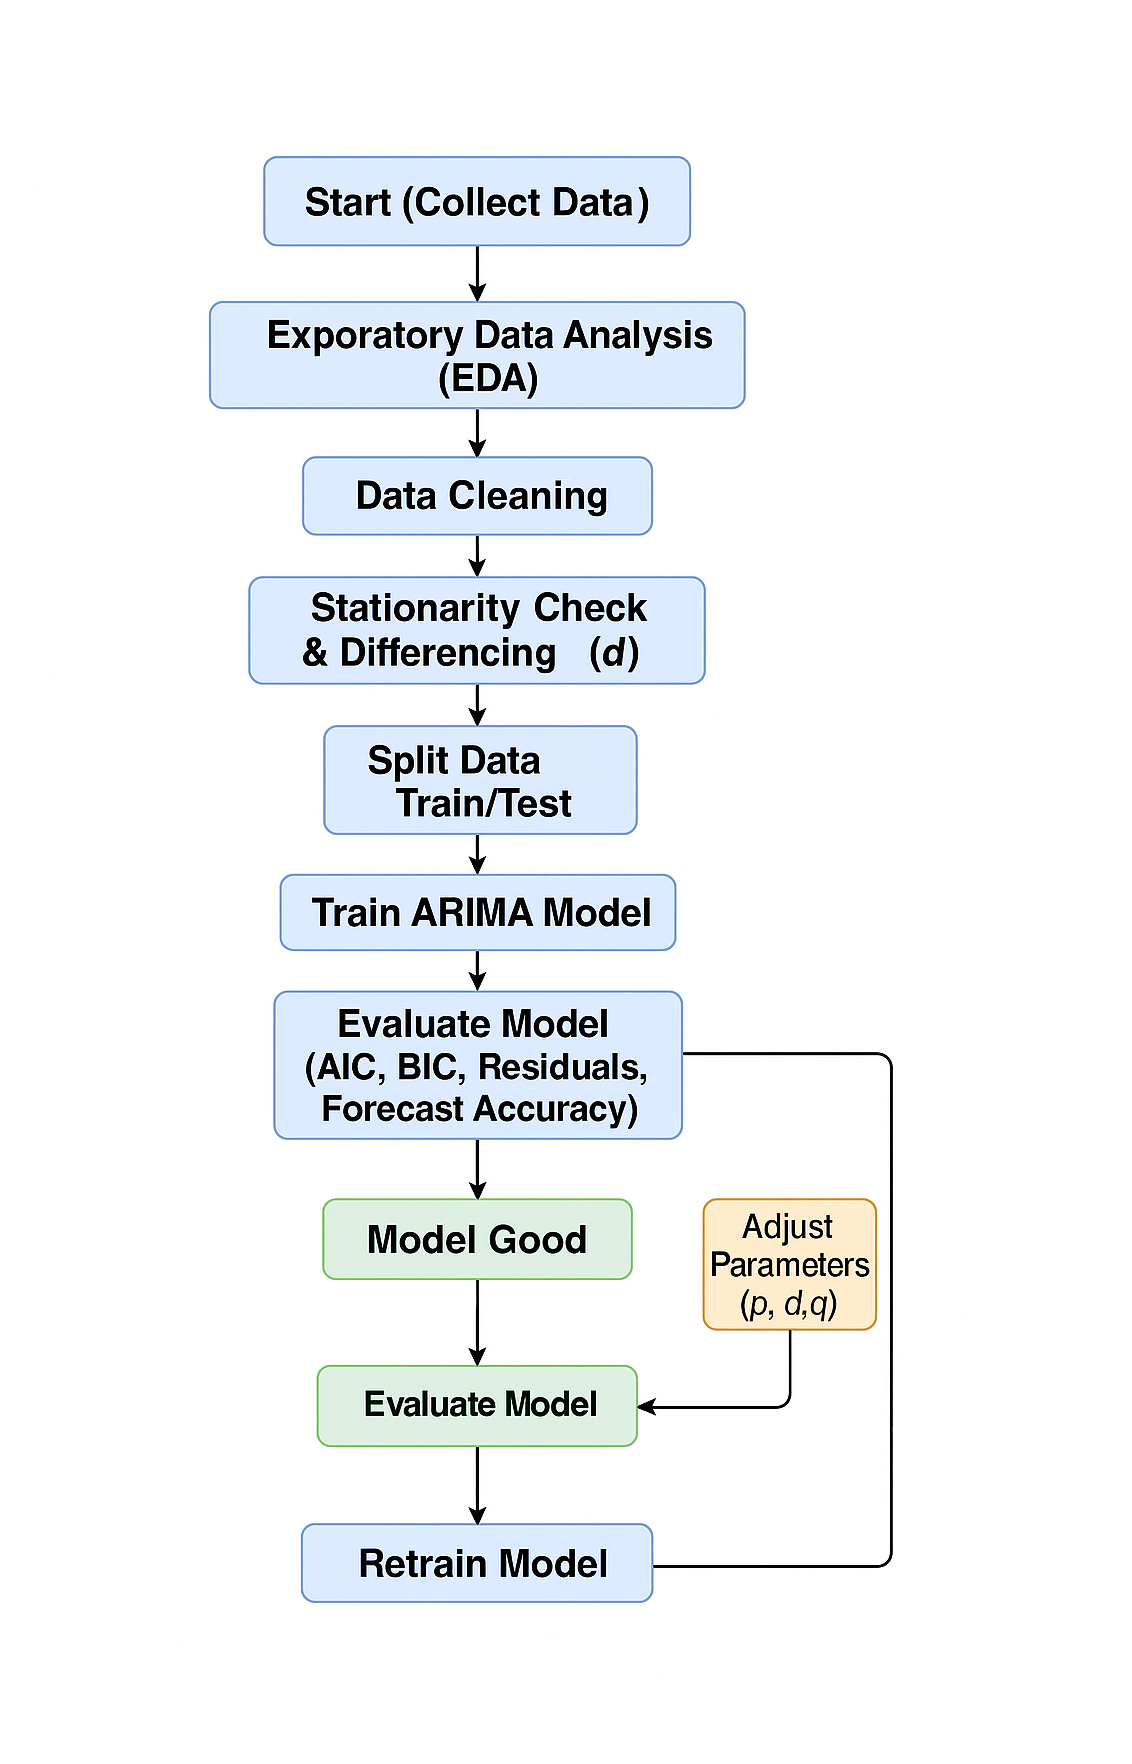

Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Date Source** : OPEC formal website    
            https://www.opec.org/opec-basket-price.html

**Type of data** : OPEC Reference Basket (ORB)  
Period : 2003-01-02 to 2025-06-27

**Framing** :  Univariate

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv'
df = pd.read_csv(file_path)
df.head()


,Date,Price
0,2003-01-02,30.05
1,2003-01-03,30.83
2,2003-01-06,30.71
3,2003-01-07,29.72
4,2003-01-08,28.86


**Data Preparation**

Step 1:  Xml file Oil price data  downloaded from the official OPEC website , after that converted it to CSV in colab



In [ ]:
import pandas as pd
import xml.etree.ElementTree as ET
from google.colab import drive

#  conn Google Drive
drive.mount('/content/drive')

#  path  XML
xml_file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/basketDayArchives.xml'

#  read XML
tree = ET.parse(xml_file_path)
root = tree.getroot()

# data and price from xml fil
dates = []
prices = []
for basket in root.findall('{http://tempuri.org/basketDayArchives.xsd}BasketList'):
    date = basket.attrib['data']
    price = float(basket.attrib['val'])
    dates.append(date)
    prices.append(price)

#  create DataFrame
df = pd.DataFrame({
    'Date': pd.to_datetime(dates),
    'Price': prices
})

#     save to CSV
csv_file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv'
df.to_csv(csv_file_path, index=False)

#    read first 5 columns
df.head()


MessageError: Error: credential propagation was unsuccessful

**Data Preparation**

Step 2: Code for Exploratory Data Analysis (EDA)

- They display general information about the data, including the number of rows and columns.

- They check if there are any missing (null) values.

- They provide statistics about the Price column.

- They ensure that the Date column is stored correctly as a datetime type.

- They detect if there are any duplicate dates.

In [ ]:
import pandas as pd

#  Read the CSV file
file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv'
df = pd.read_csv(file_path)

#  Display general information about the data
print("Data shape (rows, columns):", df.shape)
print("\nGeneral information and missing data:")
print(df.info())

#  Display the first 5 rows
print("\nFirst 5 records:")
print(df.head())

#  Check  missing data in columns
print("\nNumber of missing values per column:")
print(df.isnull().sum())

#  Descriptive statistics for the 'Price' column
print("\nDescriptive statistics for the 'Price' column:")
print(df['Price'].describe())

#  Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])
print("\n'Date' column data type after conversion:")
print(df['Date'].dtype)

#  Check for duplicate dates (optional)
duplicates = df['Date'].duplicated().sum()
print(f"\nNumber of duplicated dates: {duplicates}")


Data shape (rows, columns): (5799, 2)

General information and missing data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5799 entries, 0 to 5798
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5799 non-null   object 
 1   Price   5799 non-null   float64
dtypes: float64(1), object(1)
memory usage: 90.7+ KB
None

First 5 records:
         Date  Price
0  2003-01-02  30.05
1  2003-01-03  30.83
2  2003-01-06  30.71
3  2003-01-07  29.72
4  2003-01-08  28.86

Number of missing values per column:
Date     0
Price    0
dtype: int64

Descriptive statistics for the 'Price' column:
count    5799.000000
mean       70.377513
std        25.693673
min        12.220000
25%        50.695000
50%        68.680000
75%        88.445000
max       140.730000
Name: Price, dtype: float64

'Date' column data type after conversion:
datetime64[ns]

Number of duplicated dates: 0


**# Manual ARIMA Model**

We implemented a manual ARIMA (AutoRegressive Integrated Moving Average) model to forecast daily crude oil prices using the historical OPEC dataset.

arima(p d q)

import library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


download dataset

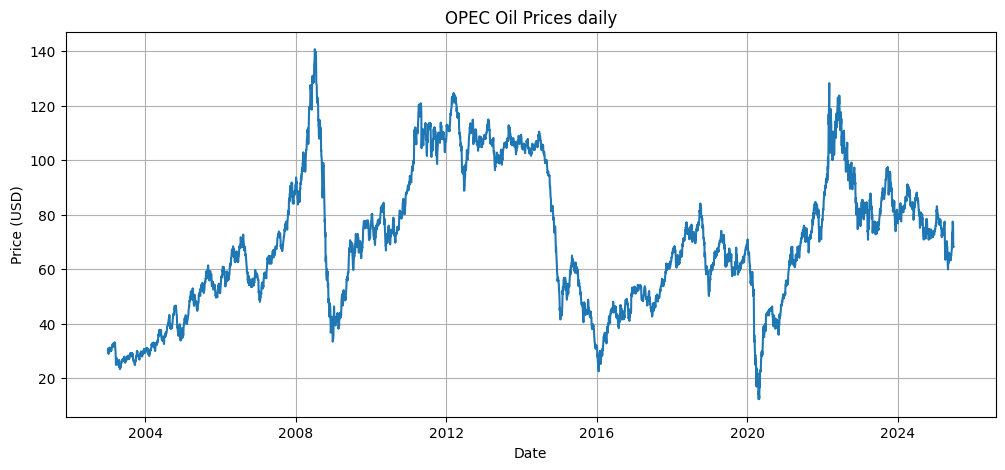

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# رسم السلسلة الزمنية
plt.figure(figsize=(12,5))
plt.plot(df['Price'])
plt.title('OPEC Oil Prices daily')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


# **Check the Stationarity using ADF**

A stationary time series is one whose statistical properties—such as mean, variance, and autocorrelation—do not change over time. This stability is important because many time series forecasting models, including ARIMA, assume stationarity to make accurate predictions.

*   If a series is ***stationary***, it means the data fluctuate around a constant mean and variance over time.
*   If ***not stationary***, the series might have trends, seasonality, or changing variance, which complicates modeling.


# To check stationarity with ADF test:
1. ADF Statistic tests the null hypothesis that the time series has a unit root .
2.   **If p-value ≤ 0.05**, you reject the null hypothesis: series is stationary.
3. **If p-value > 0.05**, you fail to reject the null  series is non-stationary : differencing is needed.



In [ ]:
# الخطوة 2: التحقق من الثبات باستخدام اختبار ADF
from statsmodels.tsa.stattools import adfuller

# تنفيذ الاختبار
result = adfuller(df['Price'])

# عرض النتائج
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Used Lags:', result[2])
print('Number of Observations:', result[3])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')


ADF Statistic: -2.969114269366679
p-value: 0.037881148719252675
Used Lags: 32
Number of Observations: 5766
Critical Values:
   1%: -3.4314846190761017
   5%: -2.862041393601955
   10%: -2.5670368899004763


# Accodrding to the result

ADF Statistic: -2.969114

p-value: 0.037881

Critical Values:
   1%, -3.4314846190761017

Critical Values:
   5%, -2.862041393601955

Critical Values:
   10%, -2.5670368899004763


---



The ADF statistic (-2.9691) is less than the 5% critical value (-2.8620), so you reject the null hypothesis of non-stationarity at the 5% significance level.

The p-value (0.0379) is less than 0.05, confirming stationarity at 5% level.

However, the ADF statistic is greater than the 1% critical value (-3.4315), so you cannot reject non-stationarity at the 1% level (which is stricter).

Conclusion:
Your time series is stationary at the 5% significance level, meaning you can proceed with modeling without differencing, or at most with minimal differencing. But depending on modeling results, differencing could still be applied if needed.

We can use d = 0


# PACF and ACF

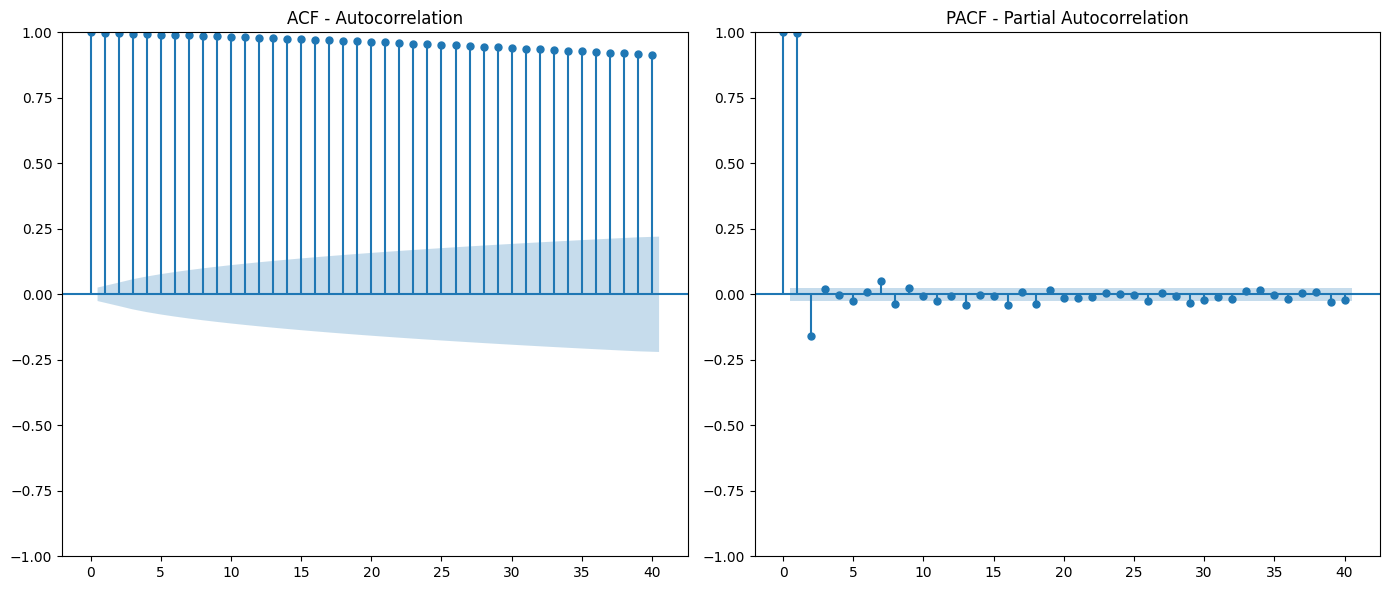

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plot_acf(df['Price'], lags=40, ax=plt.gca())
plt.title('ACF - Autocorrelation')

plt.subplot(1, 2, 2)
plot_pacf(df['Price'], lags=40, ax=plt.gca(), method='ywm')
plt.title('PACF - Partial Autocorrelation')

plt.tight_layout()
plt.show()


 ARIMA(1, 0, 1)

the code below building on 30 day we can change it) Training 80 % Testing 20%

In [ ]:

train_size = int(len(df) * 0.8)


train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")


Train size: 4639, Test size: 1160


Based on the analytic the model can be ARIMA(1,0,1)
all data 100%

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# arima training on 101
model = ARIMA(train['Price'], order=(1, 0, 1))
model_fit = model.fit()

# summary
print(model_fit.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6774.988
Date:                Wed, 30 Jul 2025   AIC                          13557.976
Time:                        13:08:53   BIC                          13583.745
Sample:                             0   HQIC                         13567.042
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4878     11.329      5.957      0.000      45.283      89.692
ar.L1          0.9987      0.001   1674.067      0.000       0.998       1.000
ma.L1          0.2485      0.009     28.667      0.0

Residual=Actual Value−Predicted Value

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


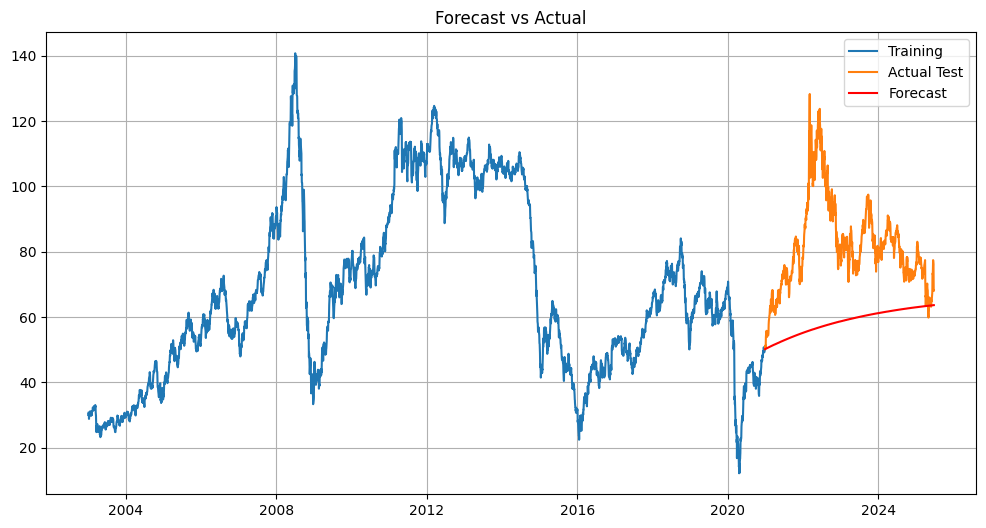

MAE: 23.3816
RMSE: 27.1457


In [ ]:
# Predict amount of steps = test size
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

#  plots
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')



Optimization the model : Parameter can be ARIMA(1,0,0) divide data

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -6913.487
Date:                Wed, 30 Jul 2025   AIC                          13832.975
Time:                        13:14:18   BIC                          13852.301
Sample:                             0   HQIC                         13839.774
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4876     11.823      5.708      0.000      44.315      90.660
ar.L1          0.9991      0.000   2062.902      0.000       0.998       1.000
sigma2         1.1518      0.010    115.447      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


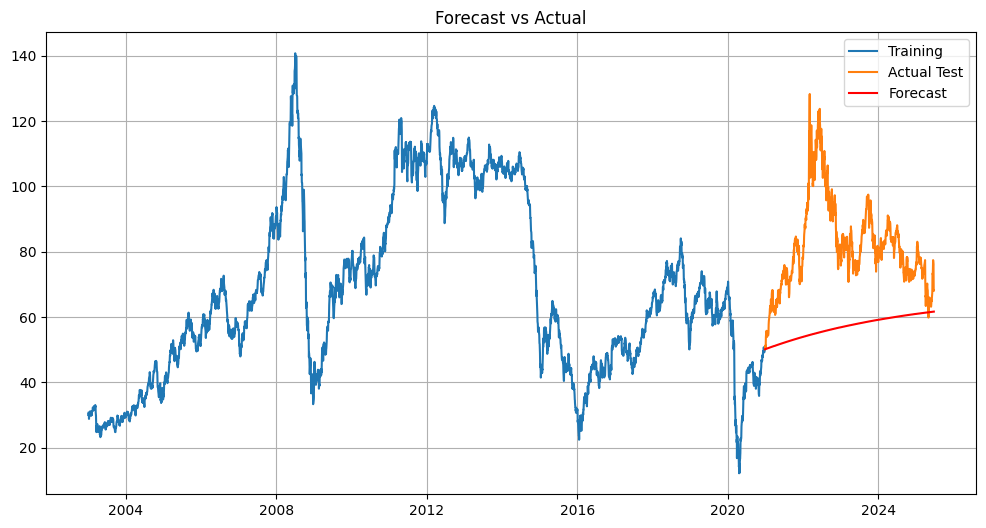

MAE: 24.9789
RMSE: 28.5601


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(1, 0, 0))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




Optimization the model : Parameter can be ARIMA(2,0,1)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(2, 0, 1)   Log Likelihood               -6774.967
Date:                Wed, 30 Jul 2025   AIC                          13559.933
Time:                        13:15:01   BIC                          13592.145
Sample:                             0   HQIC                         13571.266
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4874     11.910      5.667      0.000      44.145      90.830
ar.L1          0.9944      0.042     23.789      0.000       0.912       1.076
ar.L2          0.0044      0.042      0.104      0.9

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


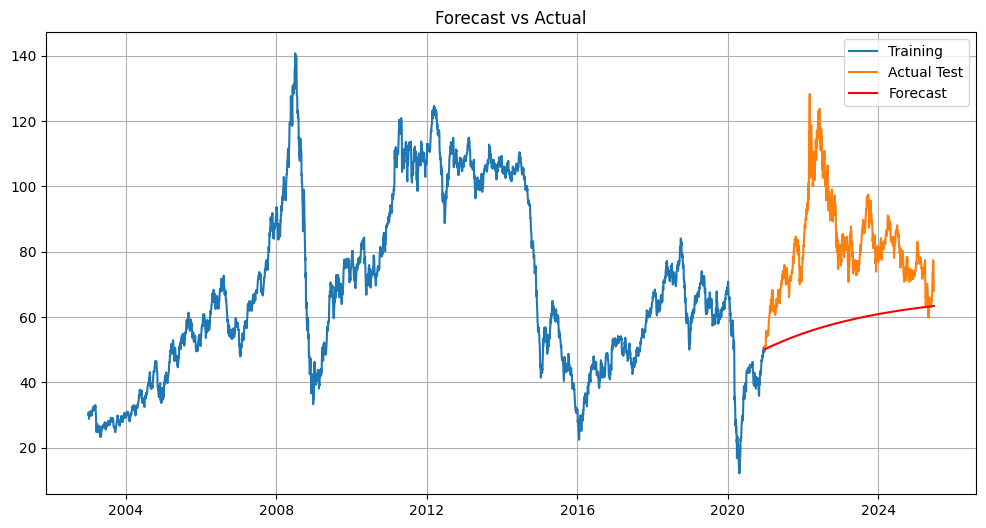

MAE: 23.6208
RMSE: 27.3593


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(2, 0, 1))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




Optimization the model : Parameter can be ARIMA(1,0,2)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -6774.995
Date:                Wed, 30 Jul 2025   AIC                          13559.990
Time:                        13:15:56   BIC                          13592.202
Sample:                             0   HQIC                         13571.323
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4878     11.230      6.010      0.000      45.478      89.498
ar.L1          0.9987      0.001   1675.639      0.000       0.998       1.000
ma.L1          0.2485      0.009     28.337      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


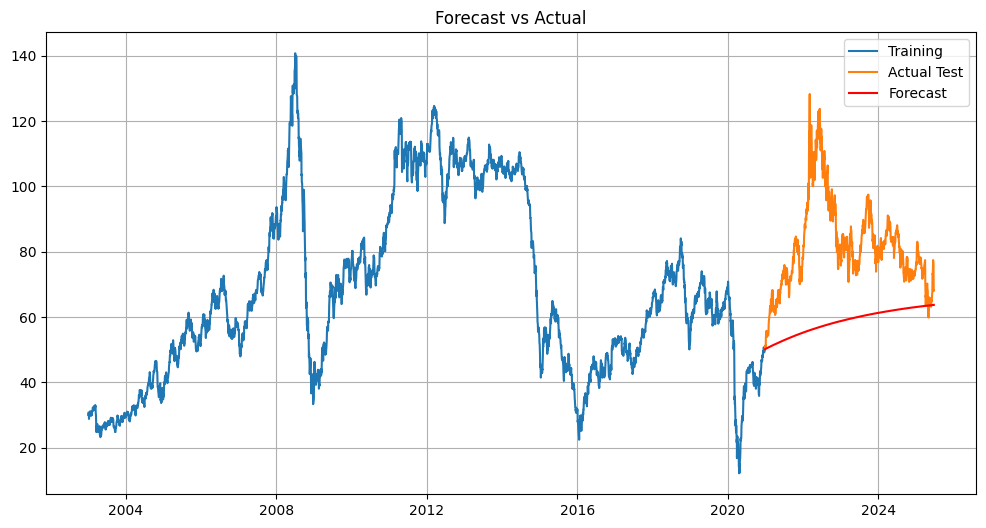

MAE: 23.3186
RMSE: 27.0892


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(1, 0, 2))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




Optimization the model : Parameter can be ARIMA(2,0,2)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -6773.069
Date:                Wed, 30 Jul 2025   AIC                          13558.138
Time:                        13:16:45   BIC                          13596.791
Sample:                             0   HQIC                         13571.737
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.1446     13.446      4.919      0.000      39.792      92.497
ar.L1          0.2014      0.138      1.464      0.143      -0.068       0.471
ar.L2          0.7966      0.137      5.798      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


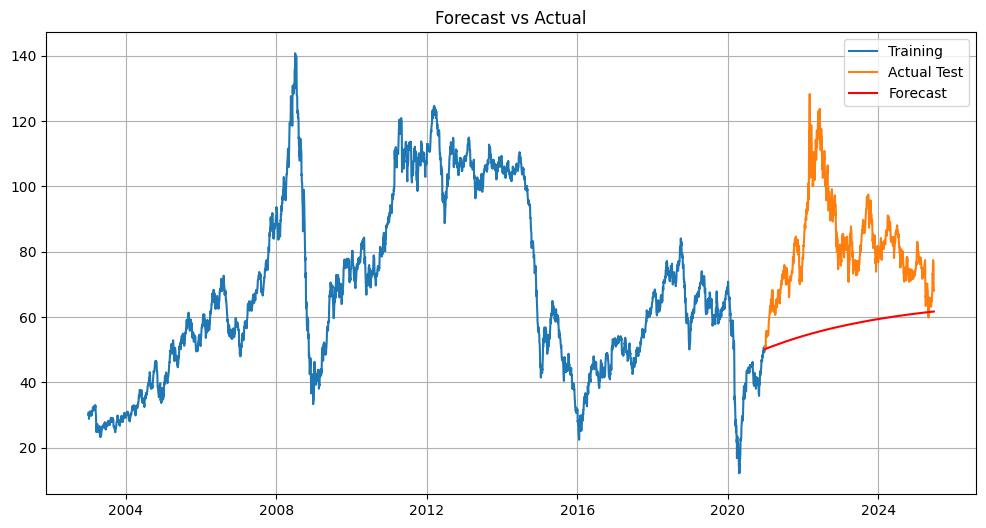

MAE: 24.7738
RMSE: 28.3534


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(2, 0, 2))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




Optimization the model : Parameter can be ARIMA(3,0,1)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -6773.075
Date:                Wed, 30 Jul 2025   AIC                          13558.150
Time:                        14:02:26   BIC                          13596.804
Sample:                             0   HQIC                         13571.749
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4768     21.754      3.102      0.002      24.840     110.114
ar.L1          0.5249      0.074      7.048      0.000       0.379       0.671
ar.L2          0.5977      0.097      6.175      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


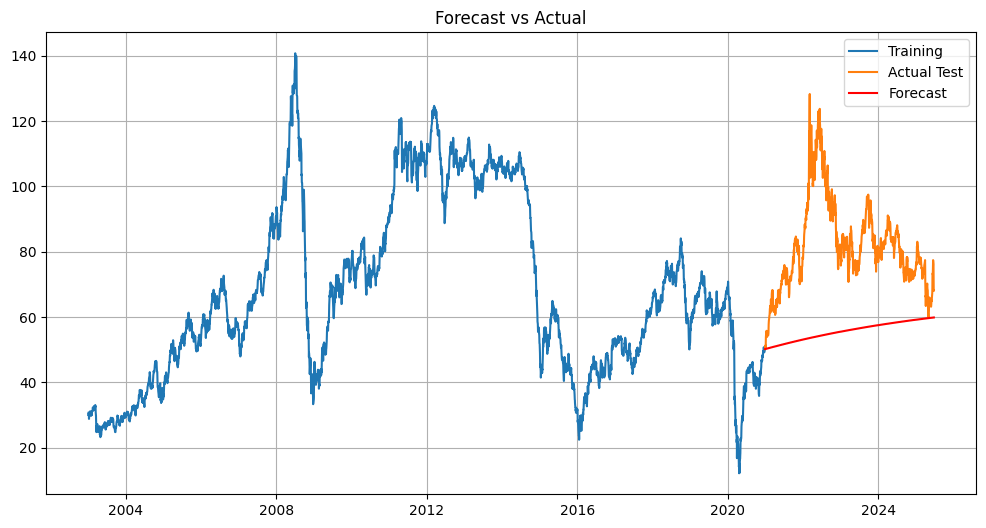

MAE: 26.2242
RMSE: 29.6474


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(3, 0, 1))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')






---



# **Model Selection Justification**
After testing multiple ARIMA configurations on the dataset, the ARIMA(1,0,2) model was selected as the most suitable for the basic forecasting task. This decision was based on the following observations:

The ARIMA(1,0,2) model achieved the lowest MAE (Mean Absolute Error) and RMSE (Root Mean Square Error) values among all tested models, indicating the highest forecasting accuracy.

Although the differences in AIC  and BIC  scores among the top-performing models—particularly between ARIMA(1,0,1) and ARIMA(1,0,2)—were minimal, the superiority of ARIMA(1,0,2) in terms of forecasting precision justified its selection.


For prediction accuracy , ARIMA(1,0,2) is the best.

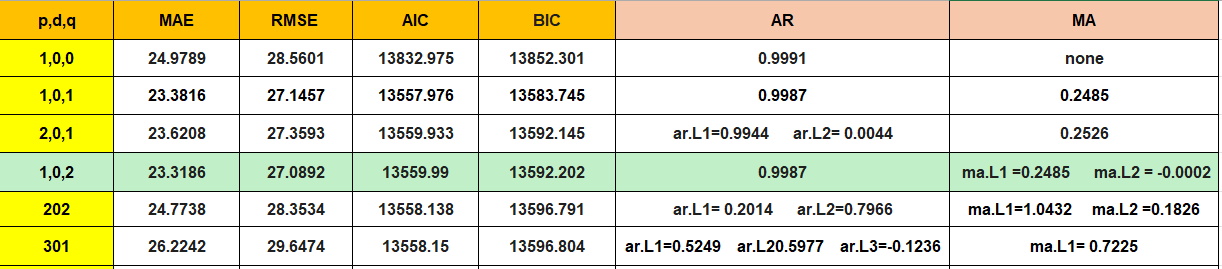

In [ ]:
!pip install pytorch_lightning --quiet
!pip install u8darts --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 42.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Now we will use ARIMA model with Backtesting

historical forecasts: 100%|██████████| 1174/1174 [40:09<00:00,  2.05s/it]


MAE: 1.1257
RMSE: 1.6286


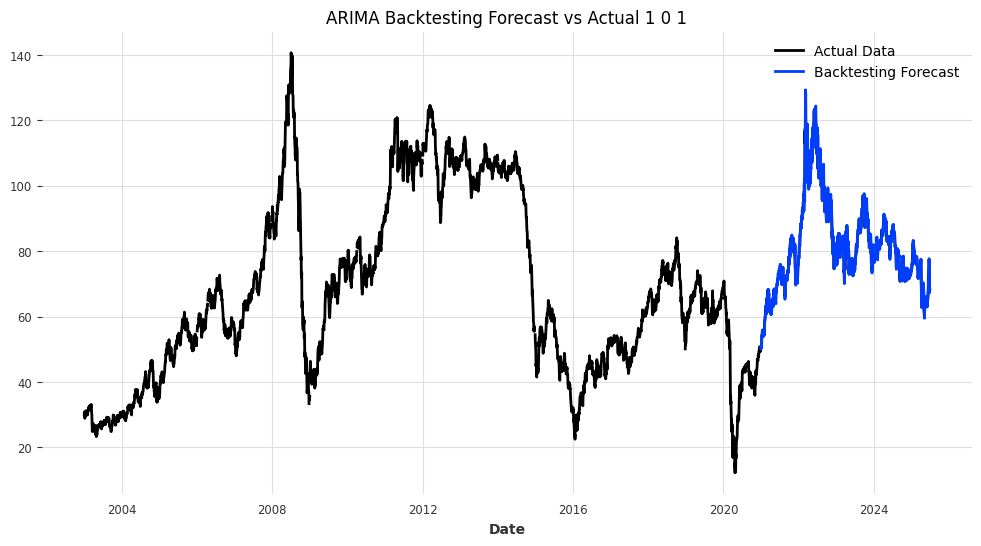

In [ ]:
from darts import TimeSeries
from darts.models import ARIMA
from darts.metrics import mae, rmse
import matplotlib.pyplot as plt

# تحويل بيانات السعر إلى TimeSeries مع ملء التواريخ المفقودة (تردد يوم عمل)
series = TimeSeries.from_series(df['Price'], fill_missing_dates=True, freq='B')

# إنشاء نموذج ARIMA مع معاملات (1,0,1)
model = ARIMA(p=1, d=0, q=1)

# تنفيذ backtesting
backtest_pred = model.historical_forecasts(
    series,
    start=0.8,            # بداية التوقع (80% من البيانات)
    forecast_horizon=1,   # توقع خطوة واحدة في كل مرة
    stride=1,             # تحريك النافذة خطوة بخطوة
    retrain=True,         # إعادة تدريب النموذج كل مرة
    verbose=True
)

# حساب مقاييس الخطأ على الفترة التي بدأ فيها التوقع
actual = series.drop_before(backtest_pred.start_time())
error_mae = mae(actual, backtest_pred)
error_rmse = rmse(actual, backtest_pred)

print(f'MAE: {error_mae:.4f}')
print(f'RMSE: {error_rmse:.4f}')

# رسم النتائج
plt.figure(figsize=(12,6))
series.plot(label='Actual Data')
backtest_pred.plot(label='Backtesting Forecast')
plt.title('ARIMA Backtesting Forecast vs Actual 1 0 1')
plt.legend()
plt.grid(True)
plt.show()


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7b007ff82520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error
historical forecasts: 100%|██████████| 1161/1161 [42:12<00:00, 

MAE: 1.1284
RMSE: 1.6304


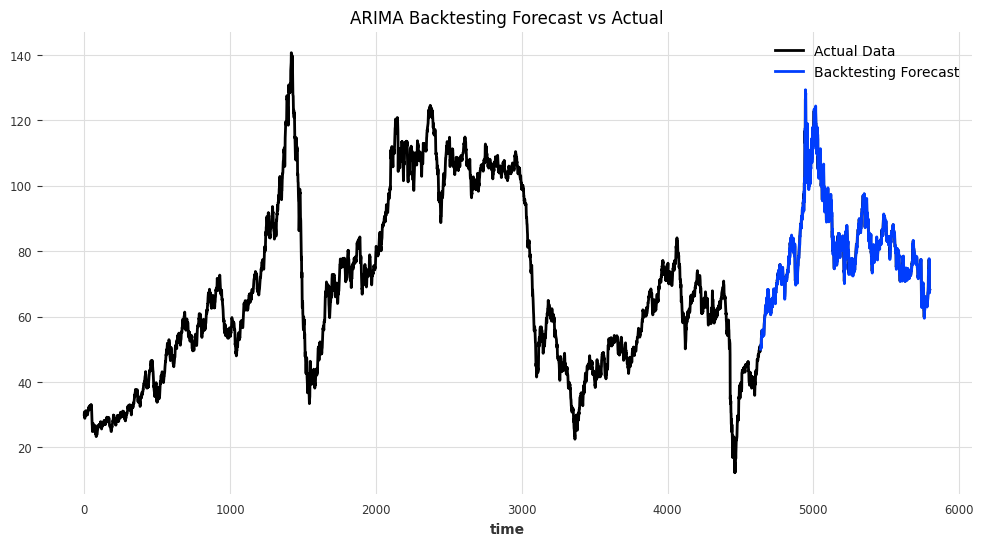

In [ ]:
from darts import TimeSeries
from darts.models import ARIMA
from darts.metrics import mae, rmse
import matplotlib.pyplot as plt

# تحويل بيانات السعر إلى TimeSeries مع ملء التواريخ المفقودة (تردد يوم عمل)
series = TimeSeries.from_series(df['Price'], fill_missing_dates=True, freq='B')

# إنشاء نموذج ARIMA مع معاملات (2,0,1)
model = ARIMA(p=2, d=0, q=1)

# تنفيذ backtesting
backtest_pred = model.historical_forecasts(
    series,
    start=0.8,            # بداية التوقع (80% من البيانات)
    forecast_horizon=1,   # توقع خطوة واحدة في كل مرة
    stride=1,             # تحريك النافذة خطوة بخطوة
    retrain=True,         # إعادة تدريب النموذج كل مرة
    verbose=True
)

# حساب مقاييس الخطأ على الفترة التي بدأ فيها التوقع
actual = series.drop_before(backtest_pred.start_time())
error_mae = mae(actual, backtest_pred)
error_rmse = rmse(actual, backtest_pred)

print(f'MAE: {error_mae:.4f}')
print(f'RMSE: {error_rmse:.4f}')

# رسم النتائج
plt.figure(figsize=(12,6))
series.plot(label='Actual Data')
backtest_pred.plot(label='Backtesting Forecast')
plt.title('ARIMA Backtesting Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()


historical forecasts: 100%|██████████| 1161/1161 [24:28<00:00,  1.26s/it]


MAE: 1.1285
RMSE: 1.6305


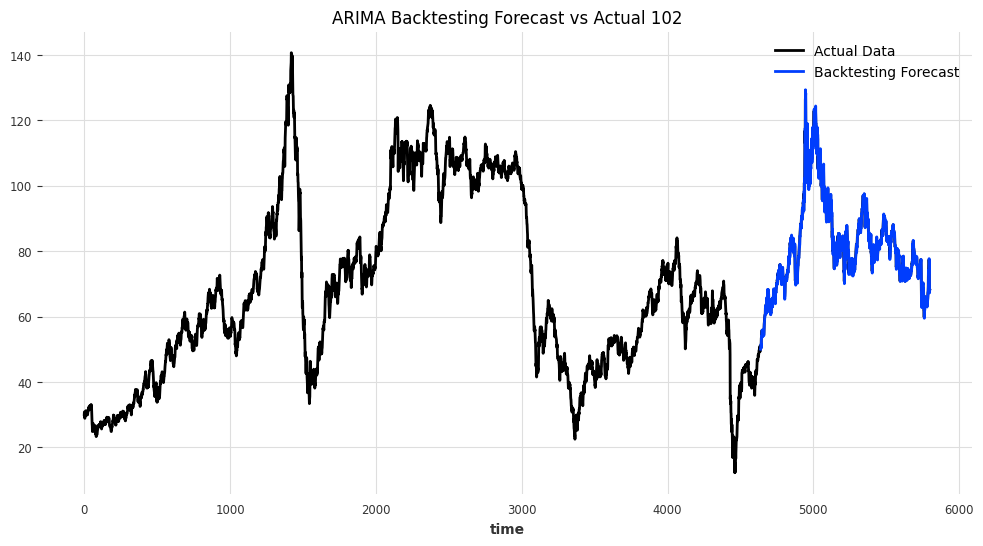

In [ ]:
from darts import TimeSeries
from darts.models import ARIMA
from darts.metrics import mae, rmse
import matplotlib.pyplot as plt

# تحويل بيانات السعر إلى TimeSeries مع ملء التواريخ المفقودة (تردد يوم عمل)
series = TimeSeries.from_series(df['Price'], fill_missing_dates=True, freq='B')

# إنشاء نموذج ARIMA مع معاملات (1,0,2)
model = ARIMA(p=1, d=0, q=2)

# تنفيذ backtesting
backtest_pred = model.historical_forecasts(
    series,
    start=0.8,            # بداية التوقع (80% من البيانات)
    forecast_horizon=1,   # توقع خطوة واحدة في كل مرة
    stride=1,             # تحريك النافذة خطوة بخطوة
    retrain=True,         # إعادة تدريب النموذج كل مرة
    verbose=True
)

# حساب مقاييس الخطأ على الفترة التي بدأ فيها التوقع
actual = series.drop_before(backtest_pred.start_time())
error_mae = mae(actual, backtest_pred)
error_rmse = rmse(actual, backtest_pred)

print(f'MAE: {error_mae:.4f}')
print(f'RMSE: {error_rmse:.4f}')

# رسم النتائج
plt.figure(figsize=(12,6))
series.plot(label='Actual Data')
backtest_pred.plot(label='Backtesting Forecast')
plt.title('ARIMA Backtesting Forecast vs Actual 102')
plt.legend()
plt.grid(True)
plt.show()


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7af5b9155da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error
historical forecasts: 100%|██████████| 1174/1174 [08:58<00:00, 

MAE: 1.1347
RMSE: 1.6336


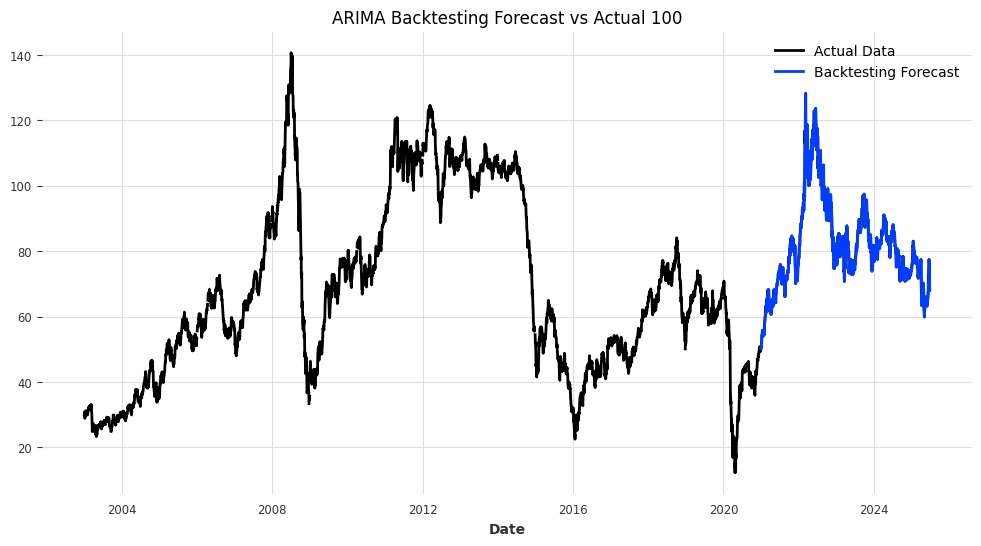

In [ ]:
from darts import TimeSeries
from darts.models import ARIMA
from darts.metrics import mae, rmse
import matplotlib.pyplot as plt

# تحويل بيانات السعر إلى TimeSeries مع ملء التواريخ المفقودة (تردد يوم عمل)
series = TimeSeries.from_series(df['Price'], fill_missing_dates=True, freq='B')

# إنشاء نموذج ARIMA مع معاملات (1,0,0)
model = ARIMA(p=1, d=0, q=0)

# تنفيذ backtesting
backtest_pred = model.historical_forecasts(
    series,
    start=0.8,            # بداية التوقع (80% من البيانات)
    forecast_horizon=1,   # توقع خطوة واحدة في كل مرة
    stride=1,             # تحريك النافذة خطوة بخطوة
    retrain=True,         # إعادة تدريب النموذج كل مرة
    verbose=True
)

# حساب مقاييس الخطأ على الفترة التي بدأ فيها التوقع
actual = series.drop_before(backtest_pred.start_time())
error_mae = mae(actual, backtest_pred)
error_rmse = rmse(actual, backtest_pred)

print(f'MAE: {error_mae:.4f}')
print(f'RMSE: {error_rmse:.4f}')

# رسم النتائج
plt.figure(figsize=(12,6))
series.plot(label='Actual Data')
backtest_pred.plot(label='Backtesting Forecast')
plt.title('ARIMA Backtesting Forecast vs Actual 100')
plt.legend()
plt.grid(True)
plt.show()


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7bfd1aff2d40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error
historical forecasts:  51%|█████     | 595/1174 [57:44<1:10:02,

MAE: 1.1282
RMSE: 1.6327


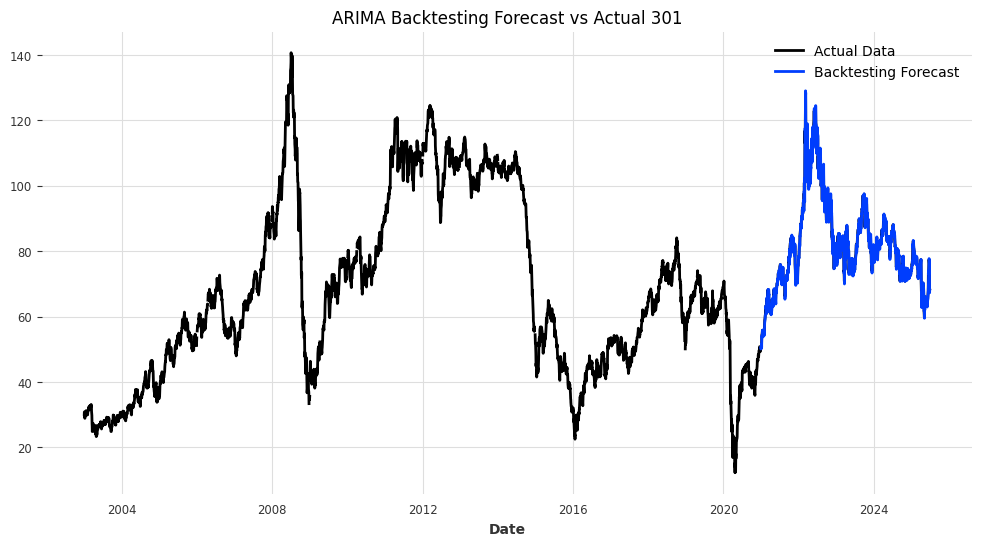

In [ ]:
from darts import TimeSeries
from darts.models import ARIMA
from darts.metrics import mae, rmse
import matplotlib.pyplot as plt

# تحويل بيانات السعر إلى TimeSeries مع ملء التواريخ المفقودة (تردد يوم عمل)
series = TimeSeries.from_series(df['Price'], fill_missing_dates=True, freq='B')

# إنشاء نموذج ARIMA مع معاملات (3,0,1)
model = ARIMA(p=3, d=0, q=1)

# تنفيذ backtesting
backtest_pred = model.historical_forecasts(
    series,
    start=0.8,            # بداية التوقع (80% من البيانات)
    forecast_horizon=1,   # توقع خطوة واحدة في كل مرة
    stride=1,             # تحريك النافذة خطوة بخطوة
    retrain=True,         # إعادة تدريب النموذج كل مرة
    verbose=True
)

# حساب مقاييس الخطأ على الفترة التي بدأ فيها التوقع
actual = series.drop_before(backtest_pred.start_time())
error_mae = mae(actual, backtest_pred)
error_rmse = rmse(actual, backtest_pred)

print(f'MAE: {error_mae:.4f}')
print(f'RMSE: {error_rmse:.4f}')

# رسم النتائج
plt.figure(figsize=(12,6))
series.plot(label='Actual Data')
backtest_pred.plot(label='Backtesting Forecast')
plt.title('ARIMA Backtesting Forecast vs Actual 301')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from darts import TimeSeries
from darts.models import ARIMA
from darts.metrics import mae, rmse
import matplotlib.pyplot as plt

# تحويل بيانات السعر إلى TimeSeries مع ملء التواريخ المفقودة (تردد يوم عمل)
series = TimeSeries.from_series(df['Price'], fill_missing_dates=True, freq='B')

# إنشاء نموذج ARIMA مع معاملات (2,0,2)
model = ARIMA(p=2, d=0, q=2)

# تنفيذ backtesting
backtest_pred = model.historical_forecasts(
    series,
    start=0.8,            # بداية التوقع (80% من البيانات)
    forecast_horizon=1,   # توقع خطوة واحدة في كل مرة
    stride=1,             # تحريك النافذة خطوة بخطوة
    retrain=True,         # إعادة تدريب النموذج كل مرة
    verbose=True
)

# حساب مقاييس الخطأ على الفترة التي بدأ فيها التوقع
actual = series.drop_before(backtest_pred.start_time())
error_mae = mae(actual, backtest_pred)
error_rmse = rmse(actual, backtest_pred)

print(f'MAE: {error_mae:.4f}')
print(f'RMSE: {error_rmse:.4f}')


plt.figure(figsize=(12,6))
series.plot(label='Actual Data')
backtest_pred.plot(label='Backtesting Forecast')
plt.title('ARIMA Backtesting Forecast vs Actual 202')
plt.legend()
plt.grid(True)
plt.show()


In time series forecasting, backtesting is a rigorous evaluation methodology whereby the predictive model is applied retrospectively on historical data to assess its forecasting performance.

Concerning the evaluation metrics obtained from backtesting, the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) values were notably lower—approximately 1.12 and 1.63, respectively—compared to those derived from the conventional 80/20 train-test split, which ranged between 23 and 26. This discrepancy indicates that backtesting offers a more robust and reliable assessment of model performance we can see the model arima(1,0,1) is the best, as detailed in the table below.



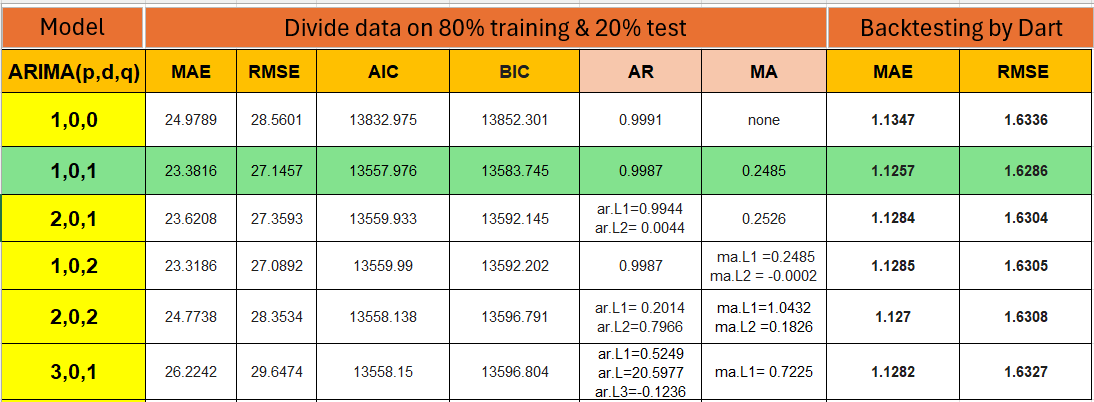

**Now we will forcating 30 days future:**
ARIMA(1,0,1) model, identified as the best-performing model based on MAE and RMSE metrics, was applied for forecasting. After being trained on the full historical series of OPEC oil prices from 2003 to 2025, it produced 30-day ahead forecasts. The plotted results show a continuation of the overall price trend with relative stability in the predicted values, indicating the model’s ability to effectively capture temporal patterns. These forecasts will be used in analyzing future scenarios of the oil market within the research paper.

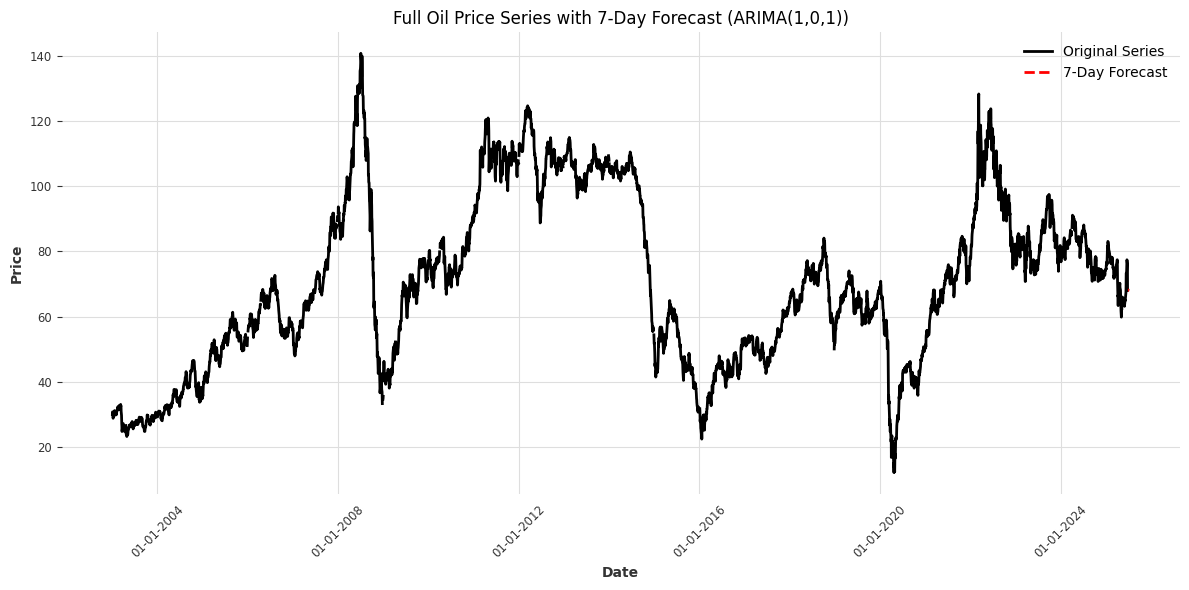

7-Day Forecast Summary:
      Date  Predicted_Price
2025-06-27        68.132990
2025-06-30        68.136889
2025-07-01        68.140782
2025-07-02        68.144668
2025-07-03        68.148547
2025-07-04        68.152419
2025-07-07        68.156285


In [ ]:
import pandas as pd
from darts import TimeSeries
from darts.models import ARIMA
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv')

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort data by date
df = df.sort_values('Date')

# Convert to TimeSeries object, filling missing dates and setting frequency to business days
series = TimeSeries.from_dataframe(df, 'Date', 'Price', fill_missing_dates=True, freq='B')

# Create and fit ARIMA model with parameters (1, 0, 1)
model = ARIMA(p=1, d=0, q=1)
model.fit(series)

# Forecast the next 7 business days
forecast = model.predict(7)

# -------- Plot 1: Full series + forecast --------
plt.figure(figsize=(12, 6))
series.plot(label='Original Series')
forecast.plot(label='7-Day Forecast', lw=2, linestyle='--', color='red')

plt.title("Full Oil Price Series with 7-Day Forecast (ARIMA(1,0,1))")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------- Display forecast summary --------
forecast_df = pd.DataFrame({
    'Date': forecast.time_index,
    'Predicted_Price': forecast.values().flatten()
})

print("7-Day Forecast Summary:")
print(forecast_df.to_string(index=False))


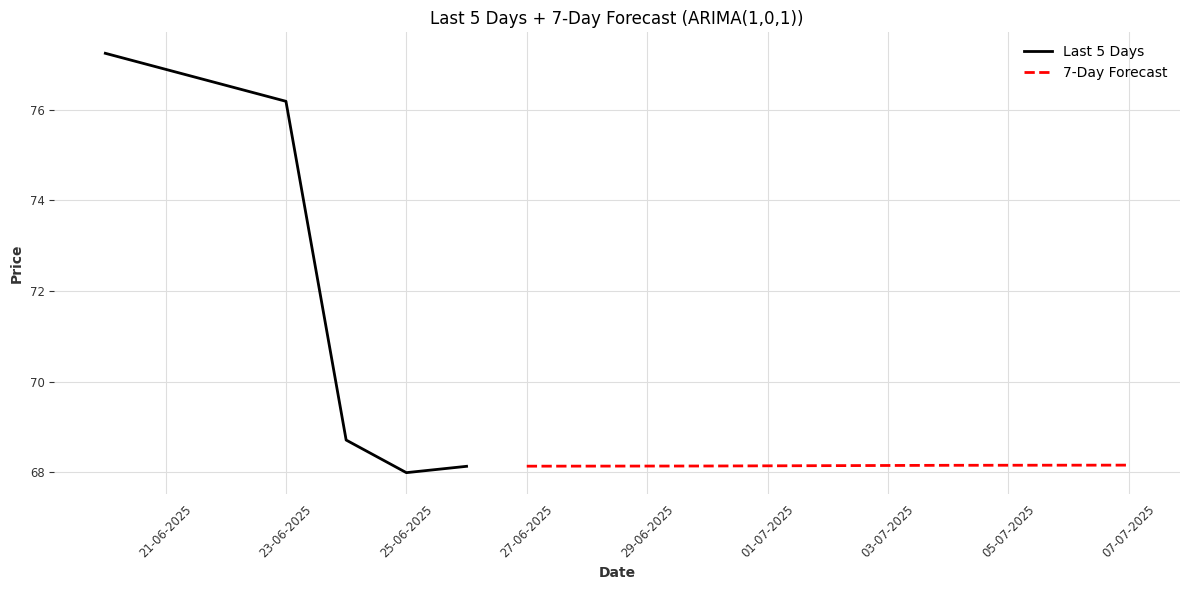

In [ ]:
# -------- Plot 2: Last 5 days + forecast --------
last_60_days = series[-5:]
combined_series = last_60_days.append(forecast)

plt.figure(figsize=(12, 6))
last_60_days.plot(label='Last 5 Days')
forecast.plot(label='7-Day Forecast', lw=2, linestyle='--', color='red')

plt.title("Last 5 Days + 7-Day Forecast (ARIMA(1,0,1))")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

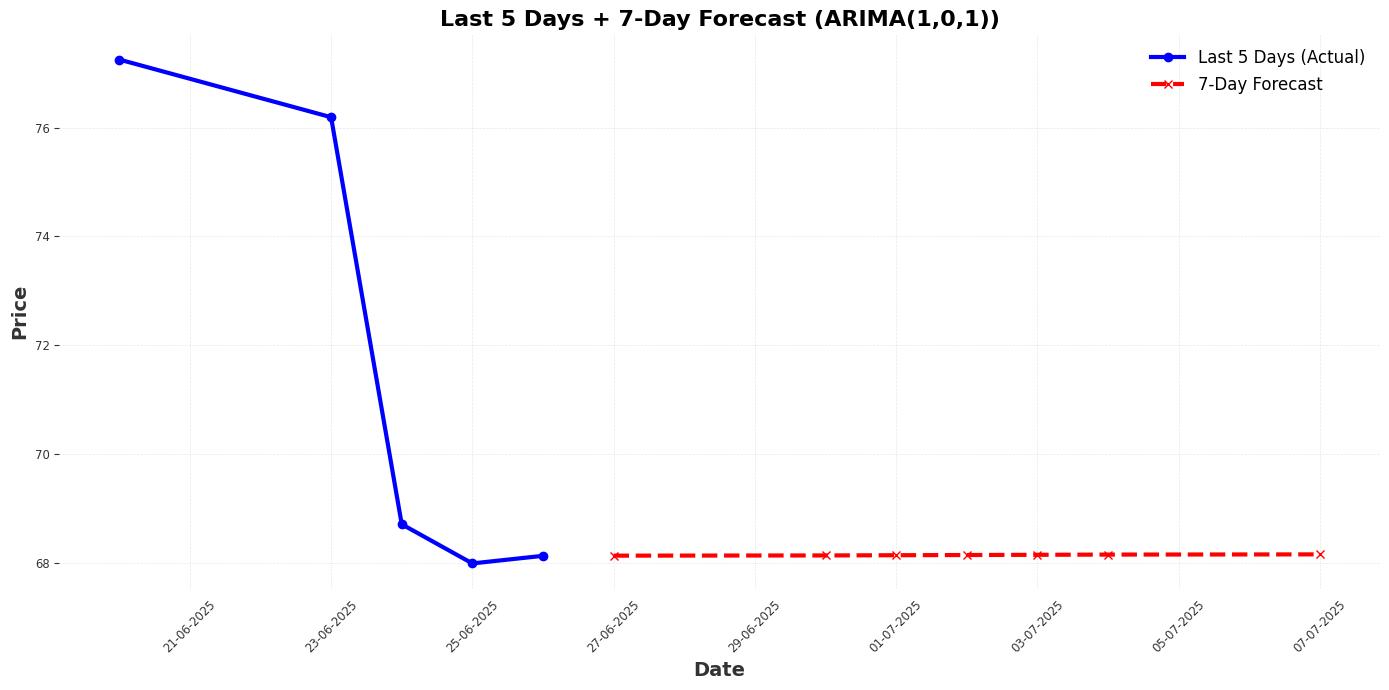

In [ ]:
import matplotlib.ticker as ticker

# -------- Plot 2: Last 5 days + forecast (More professional style) --------
last_5_days = series[-5:]
combined_series = last_5_days.append(forecast)

plt.figure(figsize=(14, 7))

# Plot actual last 5 days with markers and thicker line
last_5_days.plot(label='Last 5 Days (Actual)', lw=3, marker='o', color='blue')

# Plot forecast with dashed line, thicker and markers
forecast.plot(label='7-Day Forecast', lw=3, linestyle='--', marker='x', color='red')

plt.title("Last 5 Days + 7-Day Forecast (ARIMA(1,0,1))", fontsize=16, weight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Price", fontsize=14)

plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.7)  # Grid with minor and major lines

plt.legend(fontsize=12)
plt.xticks(rotation=45)

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

# Optionally, tighten layout
plt.tight_layout()

plt.show()


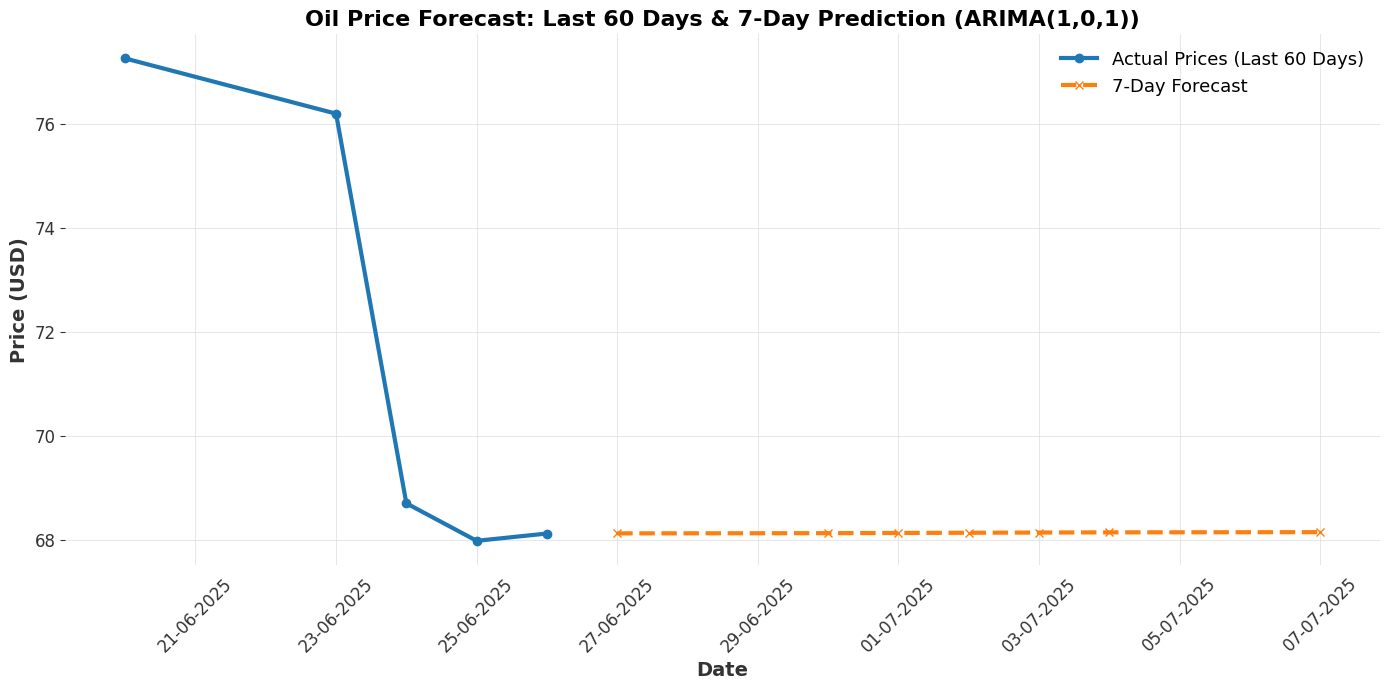

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# إعداد حجم الرسم
plt.figure(figsize=(14, 7))

# رسم البيانات الأصلية (آخر 60 يومًا) بخط سميك ونقاط
last_60_days.plot(label='Actual Prices (Last 60 Days)', lw=3, marker='o', color='#1f77b4')

# رسم التنبؤات (7 أيام) بخط متقطع، نقاط "x"، ولون مميز
forecast.plot(label='7-Day Forecast', lw=3, linestyle='--', marker='x', color='#ff7f0e')

# العنوان والمحاور
plt.title("Oil Price Forecast: Last 60 Days & 7-Day Prediction (ARIMA(1,0,1))", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Price (USD)", fontsize=14)

# الشبكة مع خطوط رئيسية وفرعية شفافة
plt.grid(which='major', linestyle='-', linewidth=0.75, alpha=0.7)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.3)

# تنسيق التواريخ على المحور الأفقي
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# الأسطورة بخط أكبر وواضحة
plt.legend(fontsize=13, loc='best')

# ضبط التباعد
plt.tight_layout()

# حفظ الرسم بدقة عالية (اختياري)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/oil_price_forecast_plot.png", dpi=300)

plt.show()




---
Auto ARIMA


---




Implement the Auto ARIMA model on the daily OPEC oil price dataset (2003–2025) and compare its forecasting performance against the manually.

Libraries Used
pandas: loading and processing data.
numpy: basic numerical.
matplotlib.pyplot: For plots.
pmdarima.auto_arima: To automatically selecting the best ARIMA model.
sklearn.metrics: For MAE and RMSE to evaluate model performance.

In [ ]:
!pip uninstall -y u8darts statsforecast pmdarima
!pip install statsforecast>=1.4 pmdarima


In [ ]:
!pip install statsforecast>=1.4 pmdarima

In [ ]:
!pip install sktime[all_extras]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 5.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.5/983.5 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.9/974.9 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 147.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 39.3 MB/s e

AutoARIMA

the best model (p,d,q) chosen : (2, 1, 3)

  MAE: 27.2022
  
  RMSE: 30.4601

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11


Best model:  ARIMA(2,1,3)(0,0,0)[0] intercept
Total fit time: 35.868 seconds

 the best model (p,d,q) chosen : (2, 1, 3)

  MAE: 27.2022
  RMSE: 30.4601


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


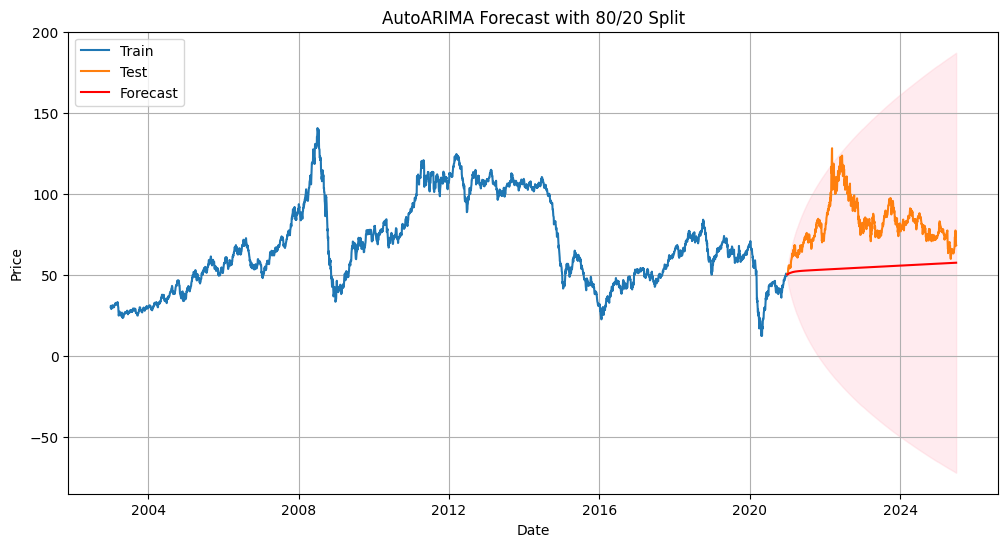

In [ ]:
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

series = df['Price']

# div to 80% and 20%
split_idx = int(len(series) * 0.8)
train, test = series[:split_idx], series[split_idx:]

# train AutoARIMA  on 80%
model = pm.auto_arima(
    train,
    start_p=0, max_p=10,
    start_q=0, max_q=10,
    max_d=3,
    seasonal=False,
    stepwise=False,          # تعطيل البحث السريع لتجربة كل التركيبات
    n_jobs=-1,               # استخدام كل الأنوية المتوفرة لتسريع التدريب
    suppress_warnings=True,
    error_action='ignore',
    trace=True               # عرض تفاصيل البحث عن المعلمات
)

# show the p d q
print("\n the best model (p,d,q) chosen :", model.order)

# predict on test
n_forecast = len(test)
forecast, conf_int = model.predict(n_periods=n_forecast, return_conf_int=True)

# evaluating
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"\n  MAE: {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")

#  plot
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.title('AutoARIMA Forecast with 80/20 Split')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


Now we will excute Auto Arima

Using Backtesting in Dart


In [ ]:
!pip install --upgrade u8darts


In [ ]:
!pip install pytorch_lightning --quiet
!pip install u8darts --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip uninstall -y numpy
!pip install --upgrade pip
!pip install numpy==1.26.4
!pip install pandas --upgrade
!pip install darts


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.8 MB/s  0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.1 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.


historical forecasts: 100%|██████████| 1644/1644 [01:37<00:00, 16.85it/s]


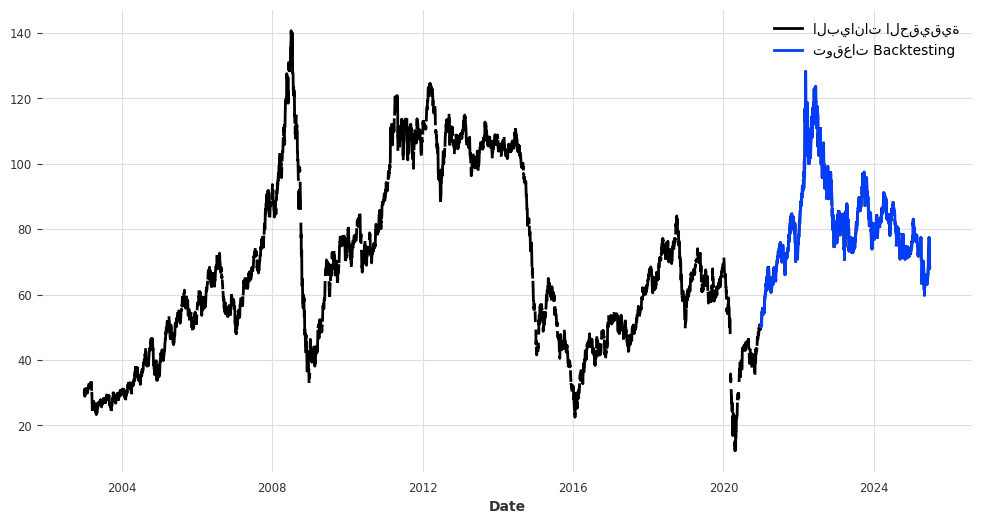

MAE: 1.1335
RMSE: 1.6334


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import AutoARIMA
from darts.metrics import mae, rmse

# تحميل البيانات
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# ملء القيم المفقودة بطريقة التقدير الأمامي (forward fill)
df['Price'] = df['Price'].ffill()

# تحويل إلى TimeSeries مع ملء التواريخ المفقودة
series = TimeSeries.from_dataframe(
    df,
    time_col='Date',
    value_cols='Price',
    fill_missing_dates=True,
    freq='D'
)

# إنشاء نموذج AutoARIMA (بدون suppress_warnings)
model = AutoARIMA(
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    seasonal=False
)

# Backtesting
backtest_forecast = model.historical_forecasts(
    series,
    start=0.8,
    forecast_horizon=1,
    stride=1,
    retrain=True,
    verbose=True
)


# عرض النتائج
plt.figure(figsize=(12, 6))
series.plot(label="البيانات الحقيقية")
backtest_forecast.plot(label="توقعات Backtesting")
plt.legend()
plt.show()

# حساب مقاييس الأداء
print(f"MAE: {mae(series.drop_before(backtest_forecast.start_time()), backtest_forecast):.4f}")
print(f"RMSE: {rmse(series.drop_before(backtest_forecast.start_time()), backtest_forecast):.4f}")
